In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import pandas as pd

# from scipy.interpolate import interp1d

from specula.mmlib.analyse_data import plot_output_data
from specula.mmlib.plot_gain_opt import plot_gain_optimization
from specula.mmlib.utils import reshape_on_mask
from specula.mmlib.compute_iffs import compute_and_save_influence_functions, compute_and_save_dcao_matrix
# from check_calibration import check_calibration

from specula.data_objects.iir_filter_data import IirFilterData

from specula.lib.make_mask import make_mask
from specula.mmlib.save_iir_filter import plot_iir_tfs

2026-07-02 15:28:47,837 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-07-02 15:28:47,968 [INFO]: [specula]: Default device is GPU number 0
2026-07-02 15:28:48,210 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-07-02 15:28:48,211 [INFO]: [specula]: Default device is GPU number 0
2026-07-02 15:28:48,220 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-07-02 15:28:48,221 [INFO]: [specula]: Default device is GPU number 0


In [2]:
# synim = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_lbt_synim.fits')

# plt.figure()
# plt.plot(np.diag(synim.T @ synim))
# plt.grid()

In [3]:

# iirfilter = IirFilterData.restore('/raid1/mmenessini/calibration/EKARUS/filter/ekarusiir_400modes_exc0_pow1.0.fits')
# iirfilter2 = IirFilterData.restore('/raid1/mmenessini/calibration/EKARUS/filter/iirfilter_400modes_exc1_pow0.8.fits')
# plot_iir_tfs(iirfilter, fs=1000, n_filters=400, delay_frames=2.5)
# plot_iir_tfs(iirfilter2, fs=1000, n_filters=400, delay_frames=2.5)

In [4]:
pdrMod3 = pd.read_csv('/raid1/mmenessini/results/EKARUS/e2e_csv/rMod3_40x40_400modes.csv')
pdrMod4 = pd.read_csv('/raid1/mmenessini/results/EKARUS/e2e_csv/rMod4_40x40_400modes.csv')
pdrMod5 = pd.read_csv('/raid1/mmenessini/results/EKARUS/e2e_csv/rMod5_40x40_400modes.csv')
pdrMod6 = pd.read_csv('/raid1/mmenessini/results/EKARUS/e2e_csv/rMod6_40x40_400modes.csv')
pdrMod7 = pd.read_csv('/raid1/mmenessini/results/EKARUS/e2e_csv/rMod7_40x40_400modes.csv')
pdrMod8 = pd.read_csv('/raid1/mmenessini/results/EKARUS/e2e_csv/rMod8_40x40_400modes.csv')

dfs = [pdrMod3,pdrMod4,pdrMod5,pdrMod6,pdrMod7,pdrMod8]
param_values = [3,4,5,6,7,8]

combined_df = pd.concat(
    [df.assign(rMod=param) for df, param in zip(dfs, param_values)],
    ignore_index=True,
)

In [5]:
def plot_datadict(datadict, ftype:str='INT', wavelengthInM:float=750e-9, find_best_conf=False):
    seeing_pd = datadict['seeing']
    starMag_pd = datadict['starMag']
    freq_pd = datadict['freq']
    sr_pd = datadict['sr']

    markers = ['s','o','^','x']

    sr_at_lambda = lambda sr,x: np.exp((750e-9/x)**2*np.log(sr))
    C = 11493*10**(1/2.5)
    flux = lambda mag: C * 10**(-mag/2.5)
    mag_from_flux = lambda f: -2.5 * np.log10(f / C)

    seeings = np.array([1.5,2.0,2.5])
    starMags = np.array([1,3,5,7,9,11,13],dtype=int)
    freqs = np.array([200,500,1000])
    fig1 = plt.figure(figsize=(16,6), num=1)
    if find_best_conf:
        fig2 = plt.figure(figsize=(16, 6), num=2)

    for j, seeing in enumerate(seeings):
        # Setup axis for Figure 1 (SR)
        ax1 = fig1.add_subplot(1, 3, j + 1)
        ax1.set_title(f'{seeing:1.1f}" seeing', y=1.2,fontsize=12*1.4)
        
        # Setup axis for Figure 2 (bestRmod), if applicable
        if find_best_conf:
            ax2 = fig2.add_subplot(1, 3, j + 1)
            ax2.set_title(f'{seeing:1.1f}" seeing', y=1.2,fontsize=12*1.4)
            
        # --- Loop for Figure 1 ---
        for jf,freq in enumerate(freqs):
            srdata = sr_pd[np.logical_and(seeing_pd == seeing, freq_pd == freq)]
            srvec = sr_at_lambda(srdata, wavelengthInM)
            magvec = starMag_pd[np.logical_and(seeing_pd == seeing, freq_pd == freq)]
            
            if find_best_conf:
                magvec = starMags.copy()
                srvec = np.zeros(len(magvec))
                bestRmod = np.zeros(len(magvec)) # Will be overwritten each loop, leaving the last freq intact
                for k, mag in enumerate(starMags):
                    srdata = sr_pd[np.logical_and(np.logical_and(seeing_pd == seeing, freq_pd == freq), starMag_pd == mag)]
                    srvec[k] = datadict['sr'].loc[srdata.idxmax()]
                    bestRmod[k] = datadict['rMod'].loc[srdata.idxmax()]
                srvec = sr_at_lambda(srvec, wavelengthInM)
                
            # Plot on Figure 1 (SR) -- primary axis is flux
            ax1.plot(
                flux(magvec), srvec, 
                linestyle='-', 
                linewidth=2, 
                marker=markers[jf], 
                markersize=6, 
                markerfacecolor='white', 
                markeredgewidth=2, 
                label=f'{freq:1.0f} Hz, {ftype}'
            )
            
        # --- Plot for Figure 2 (Using the last freq's bestRmod) -- primary axis is flux---
        if find_best_conf:
            ax2.plot(
                flux(starMags), bestRmod, 
                linestyle='-', 
                linewidth=2, 
                marker=markers[jf], 
                markersize=6, 
                markerfacecolor='white', 
                markeredgewidth=2, 
                label=f'{freq:1.0f} Hz, {ftype}' # Uses the last 'freq' from the loop above
            )

        # --- Formatting Figure 1 ---
        ax1.set_xlabel('Flux [phot/subap/ms]',fontsize=13)
        ax1.set_xticks(flux(starMags))
        secax1 = ax1.secondary_xaxis('top', functions=(mag_from_flux, flux))
        secax1.set_xlabel('WFS Magnitude', labelpad=10,fontsize=13)
        secax1.set_xticks(flux(starMags))
        secax1.set_xticklabels([str(int(val)) for val in starMags],fontsize=8*1.4)
        
        if j == 0:
            ax1.set_ylabel(f'SR {wavelengthInM*1e+9:1.0f} nm',fontsize=10*1.4)
        ax1.set_ylim([0, 1])
        ax1.set_yticks(np.arange(11) * 0.1)
        ax1.grid(which='both', alpha=0.3) 
        ax1.legend(loc='upper left', fontsize=8*1.4, title_fontsize=10*1.4)
        ax1.set_xscale('log')

        # --- Formatting Figure 2 ---
        if find_best_conf:
            ax2.set_xlabel('Flux [phot/subap/ms]',fontsize=13)
            ax2.set_ylim([2.5, 7.5])
            ax2.set_xticks(flux(starMags))
            ax2.set_xscale('log')
            secax2 = ax2.secondary_xaxis('top')
            secax2.set_xlabel('WFS Magnitude', labelpad=10,fontsize=13)
            secax2.set_xticks(flux(starMags))
            secax2.set_xticklabels([str(val) for val in starMags],fontsize=8*1.4)
            
            if j == 0:
                ax2.set_ylabel('bestRmod')
            
            ax2.grid(which='both', alpha=0.3) 
            ax2.legend(fontsize=8*1.4, title_fontsize=10*1.4)

    fig1.tight_layout()
    if find_best_conf:
        fig2.tight_layout()

In [6]:


# # plot_datadict(pdrMod3,wavelengthInM=Iband)
# # plot_datadict(pdrMod4,wavelengthInM=Iband)
# # plot_datadict(pdrMod5,wavelengthInM=Iband)
# # plot_datadict(pdrMod6,wavelengthInM=Iband)
# # plot_datadict(pdrMod7,wavelengthInM=Iband

# pdrMod7close = pd.read_csv('/raid1/mmenessini/results/EKARUS/e2e_csv/rMod7_r-0.20_40x40_400modes.csv')
 
# plot_datadict(pdrMod7close,wavelengthInM=Iband)
# # plot_datadict(combined_df,find_best_conf=True,wavelengthInM=Iband)

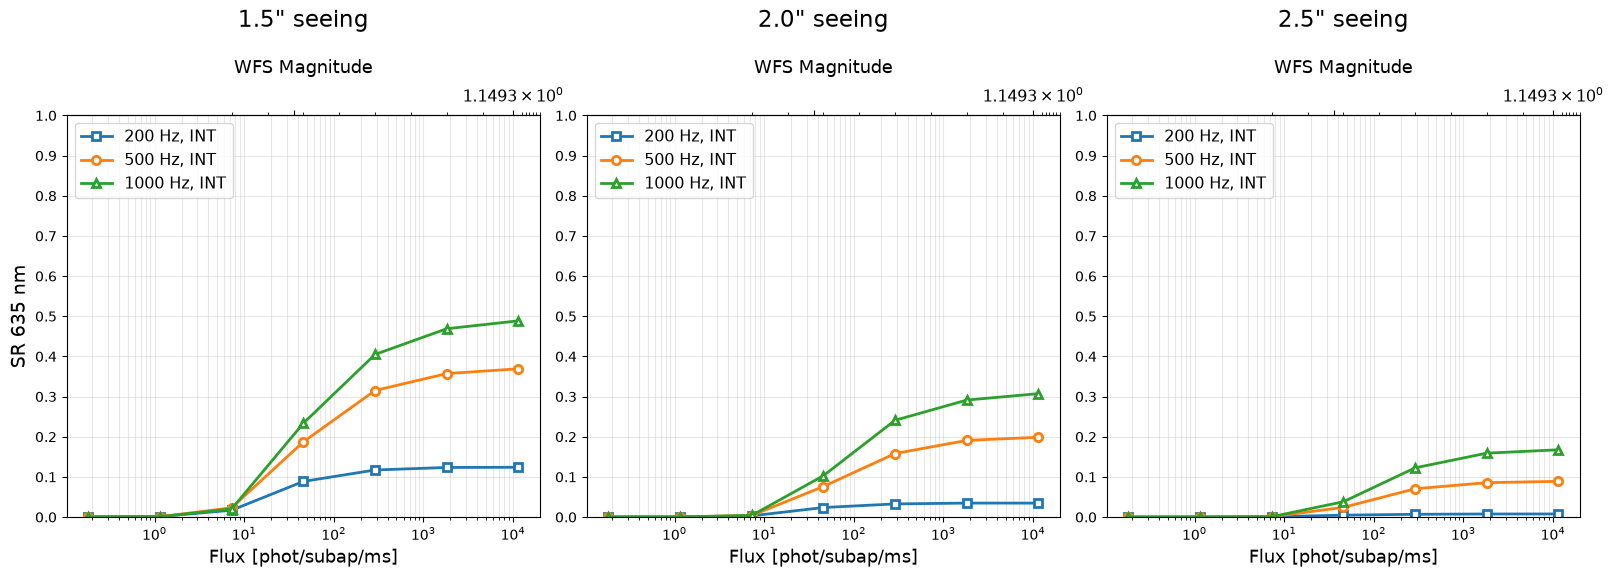

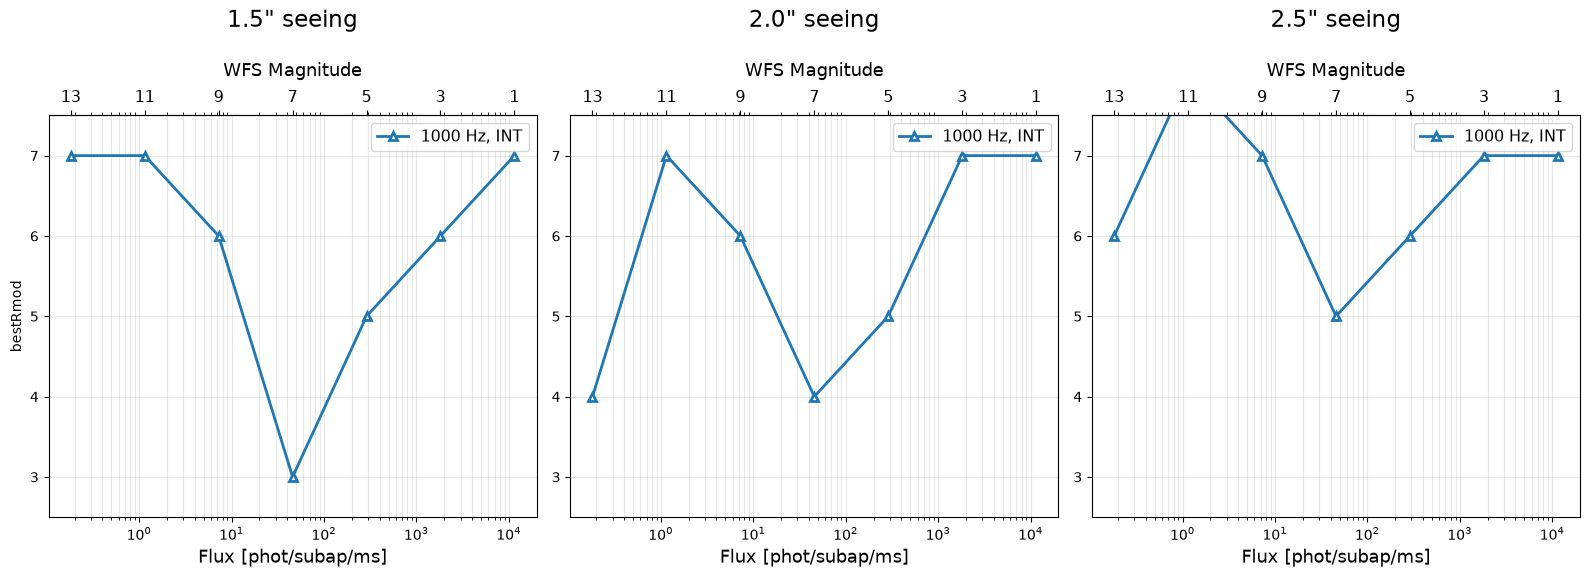

In [7]:
Iband = 635e-9
plot_datadict(combined_df,find_best_conf=True,wavelengthInM=Iband)

In [8]:
def find_best_conf(datadict,seeing,mag):
    seeing_pd = datadict['seeing']
    starMag_pd = datadict['starMag']
    sr_pd = datadict['sr']
    srdata = sr_pd[np.logical_and(seeing_pd == seeing, starMag_pd == mag)]
    idx = srdata.idxmax()
    return datadict.loc[idx]

In [9]:
best = find_best_conf(combined_df,seeing=1.5,mag=11)
print(best)

seeing          1.5
freq            250
starMag          11
sr         0.008653
gain            0.4
filter          INT
rMod              6
Name: 264, dtype: object


In [10]:
matrix_view = combined_df.pivot(index='seeing', columns='starMag', values='sr')

ValueError: Index contains duplicate entries, cannot reshape

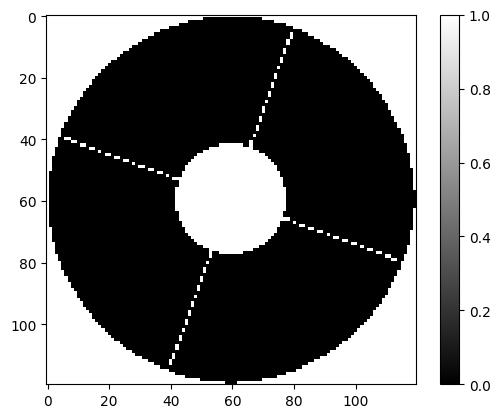

In [ ]:
mask = fits.getdata('/raid1/mmenessini/calibration/EKARUS/mask/bin_mask.fits')
mask = fits.getdata('/raid1/mmenessini/calibration/EKARUS/mask/pup_mask.fits')
# mask = fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/copernico_pupil_120pixels.fits')
# mask = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/DM468_mask.fits')

plt.figure()
plt.imshow(mask,cmap='gray')
plt.colorbar()

In [ ]:
# pupil = fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/copernico_pupil_120pixels.fits')

# plt.figure()
# plt.imshow(pupil,cmap='gray',origin='lower')
# plt.colorbar()

In [ ]:
# mask = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/mask.fits')
# coords = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/act_coords.fits')
# eigvals = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/eigenvalues.fits')

# plt.figure()
# plt.imshow(pupil,cmap='gray',origin='lower')
# plt.scatter(coords[0],coords[1],c='red',s=1)

# L = 1
# plt.figure()
# plt.loglog(np.arange(len(eigvals[:-L]))+1,eigvals[:-L])
# plt.grid(which='both',alpha=0.3)

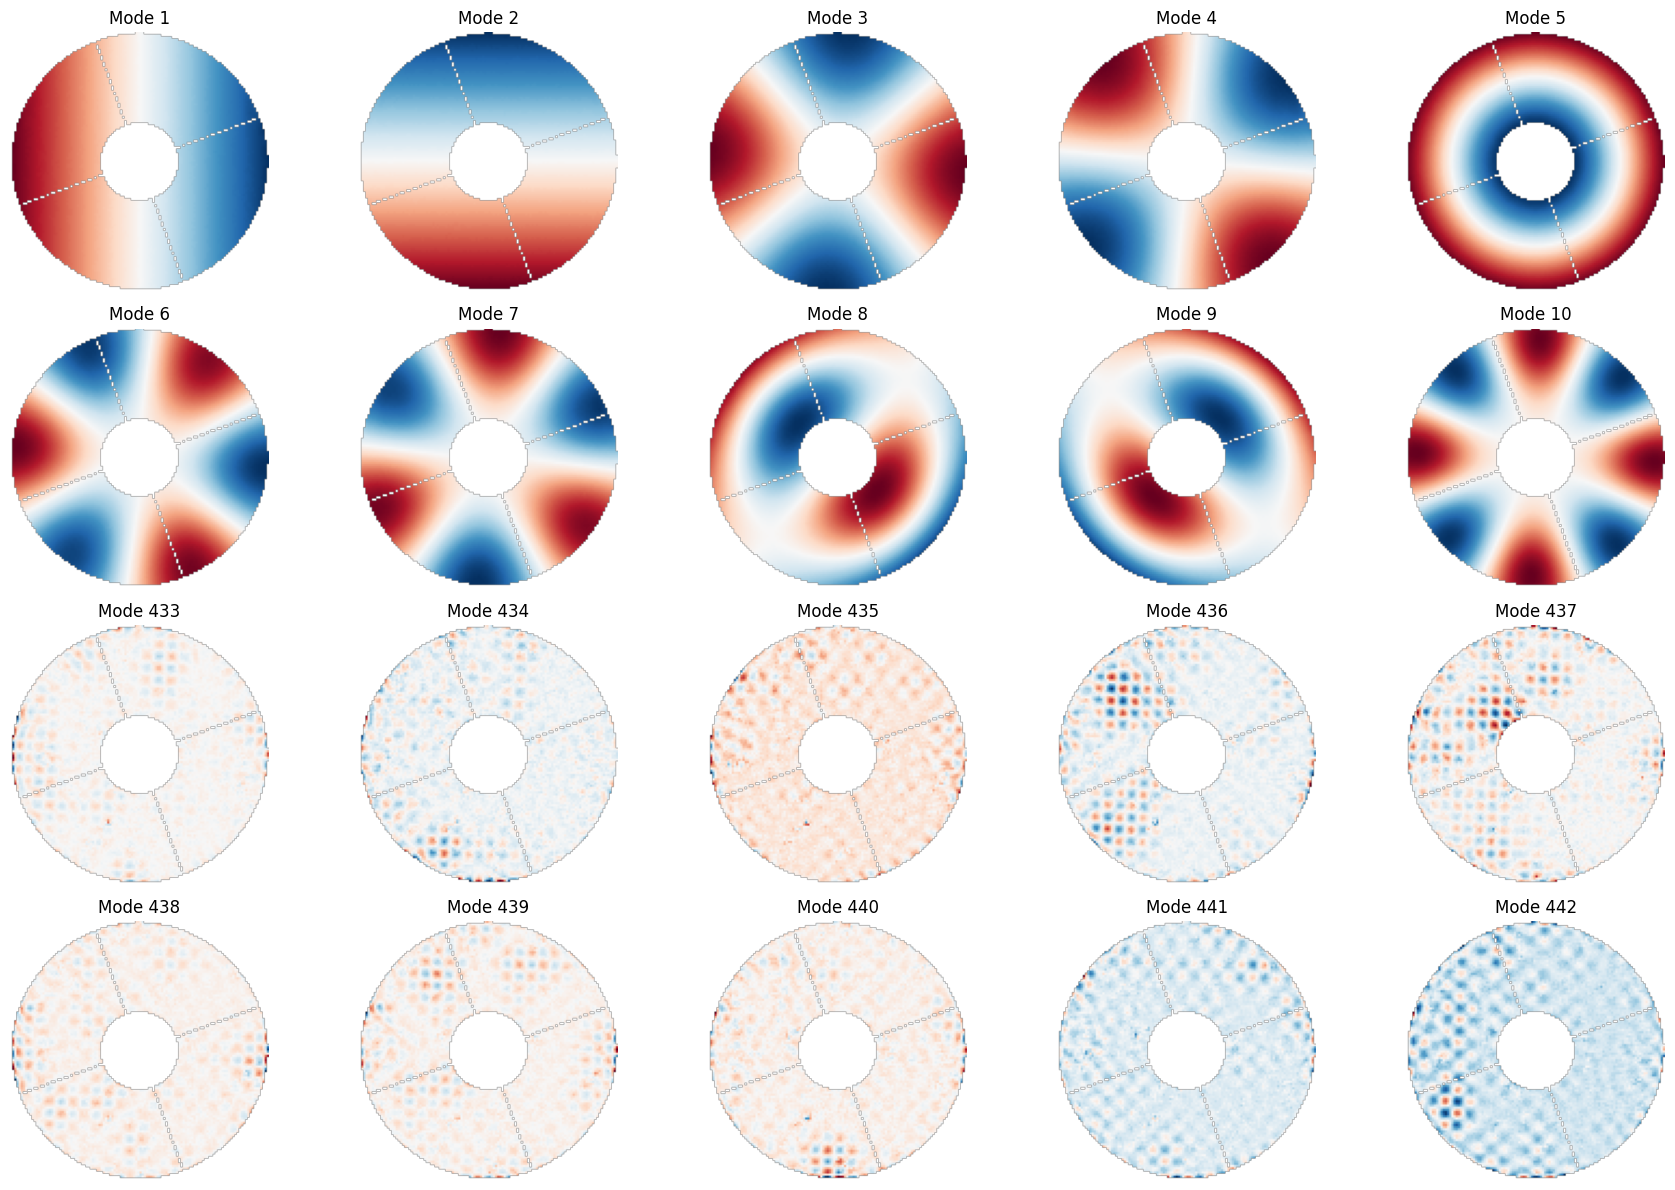

In [ ]:
kl_basis = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/DM468_kl_inv.fits')
fname = '/raid1/mmenessini/calibration/EKARUS/pupilstop/DM468_120pixels.fits' #copernico_pupil_120pixels.fits'
hdu = fits.open(fname)
pupil_mask = hdu[1].data

max_modes = min(20, kl_basis.shape[0])

# Create a mask array for display
mode_display = np.zeros((max_modes, pupil_mask.shape[0], pupil_mask.shape[1]))

# Place each mode vector into the 2D pupil shape
idx_mask = np.where(pupil_mask)
mode_ids = np.zeros(max_modes,dtype=int)
for i in range(max_modes//2):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = i+1
    mode_img[idx_mask] = kl_basis[i]
    mode_display[i] = mode_img
for i in range(max_modes//2,max_modes):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = kl_basis.shape[0]-max_modes+i
    mode_img[idx_mask] = kl_basis[mode_ids[i]]
    mode_display[i] = mode_img

# Plot the reshaped modes
n_rows = int(np.round(np.sqrt(max_modes)))
n_cols = int(np.ceil(max_modes / n_rows))
plt.figure(figsize=(18, 12))
for i in range(max_modes):
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(np.ma.masked_array(mode_display[i],mask=1-pupil_mask),origin='lower',cmap='RdBu')
    plt.title(f'Mode {mode_ids[i]}')
    plt.axis('off')
plt.tight_layout()

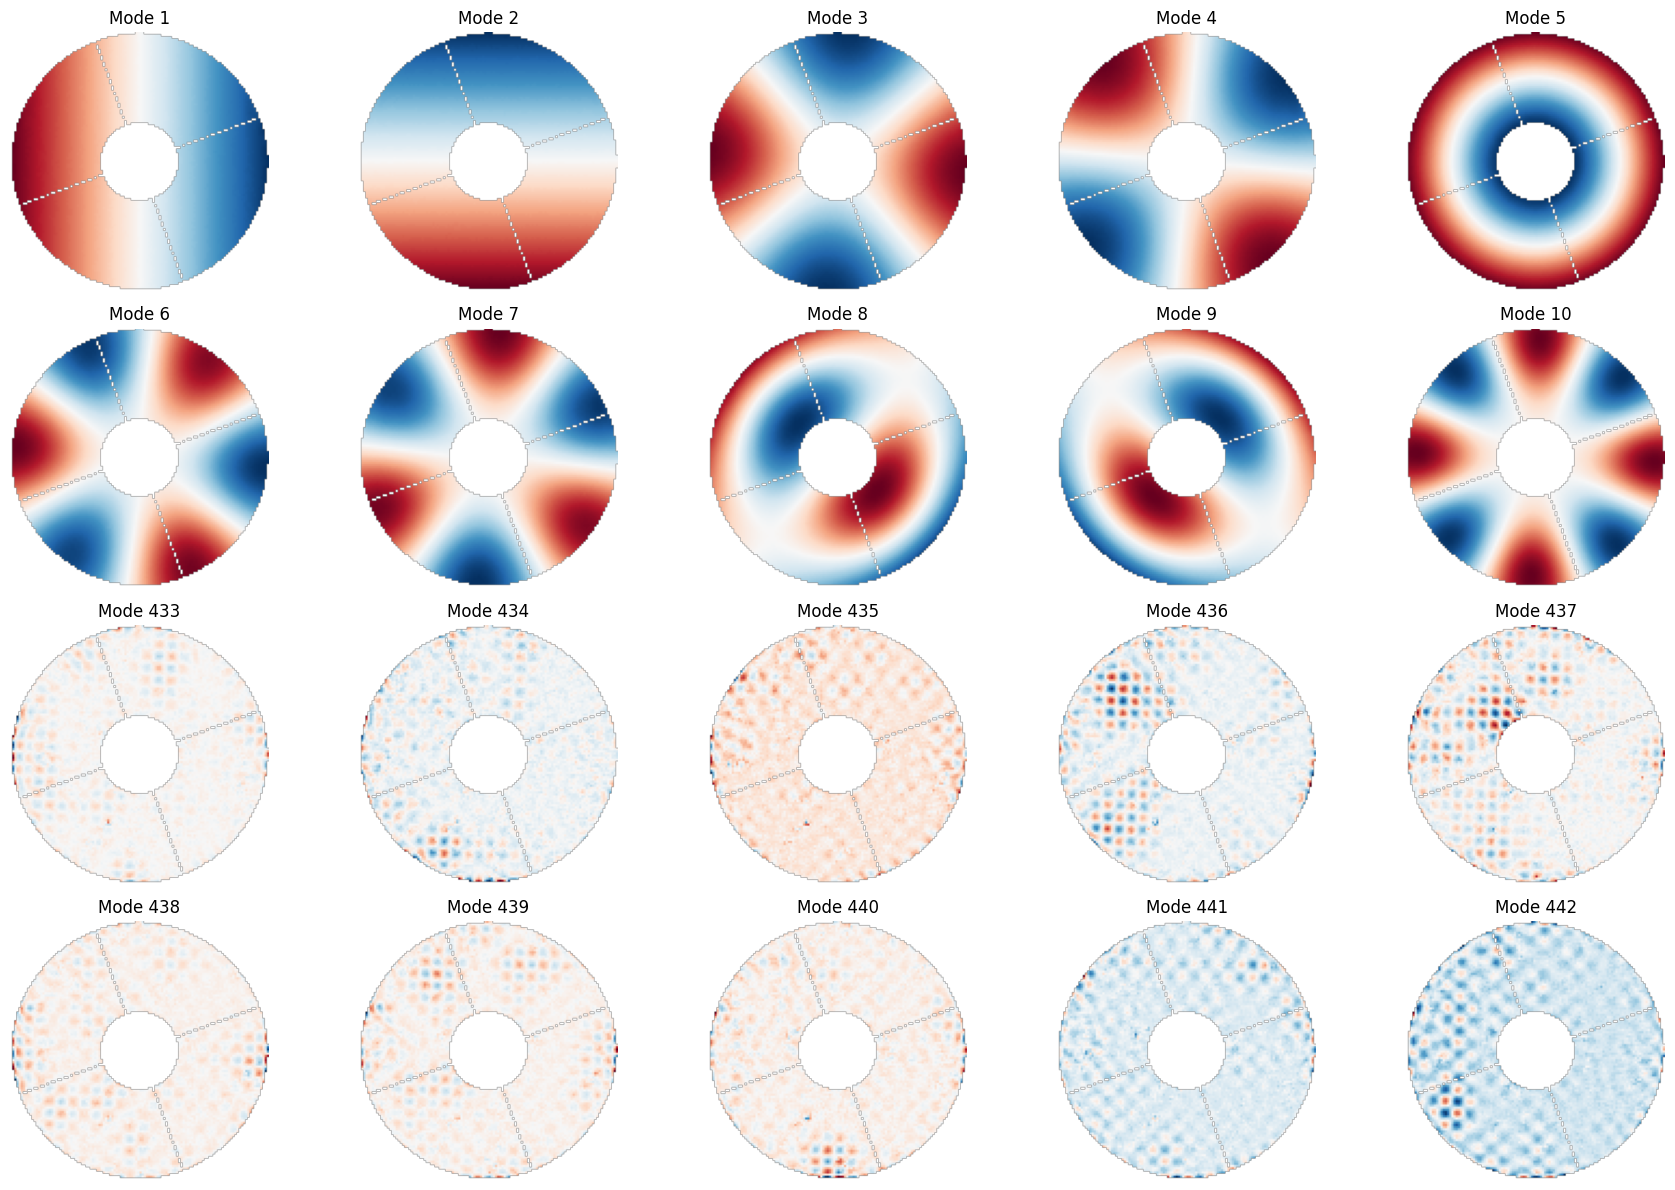

In [ ]:
iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/DM468_ifunc.fits')
m2c = fits.getdata('/raid1/mmenessini/calibration/EKARUS/m2c/DM468_m2c.fits')

kl_basis = (iffs @ m2c).T

for i in range(max_modes//2):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = i+1
    mode_img[idx_mask] = kl_basis[i]
    mode_display[i] = mode_img
for i in range(max_modes//2,max_modes):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = kl_basis.shape[0]-max_modes+i
    mode_img[idx_mask] = kl_basis[mode_ids[i]]
    mode_display[i] = mode_img

# Plot the reshaped modes
n_rows = int(np.round(np.sqrt(max_modes)))
n_cols = int(np.ceil(max_modes / n_rows))
plt.figure(figsize=(18, 12))
for i in range(max_modes):
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(np.ma.masked_array(mode_display[i],mask=1-pupil_mask),origin='lower',cmap='RdBu')
    plt.title(f'Mode {mode_ids[i]}')
    plt.axis('off')
plt.tight_layout()

In [ ]:
from specula.mmlib.compute_rec import rec_noise
from specula.mmlib.utils import get_pupil_mask

frame16 = fits.getdata('/raid1/mmenessini/calibration/XAO/frames/pyr0.0_16x16_frame.fits')[0]
frame48 = fits.getdata('/raid1/mmenessini/calibration/XAO/frames/pyr3.0_48x48_frame.fits')[0]

sn16 = fits.getdata('/raid1/mmenessini/calibration/XAO/slopenulls/pyr0.0_16x16_sn.fits')
sn48 = fits.getdata('/raid1/mmenessini/calibration/XAO/slopenulls/pyr3.0_48x48_sn.fits')

mask16 = get_pupil_mask(npix=120,filepath='/raid1/mmenessini/calibration/XAO/pupils/pyr_pupdata_16x16.fits')
mask48 = get_pupil_mask(npix=120,filepath='/raid1/mmenessini/calibration/XAO/pupils/pyr_pupdata_48x48.fits')

# flux = np.sum(frame48)

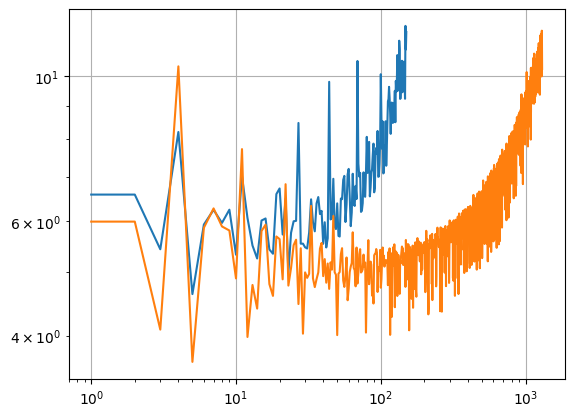

In [ ]:
rec = fits.getdata('/raid1/mmenessini/calibration/XAO/rec/pyr0.0_16x16_150modes_rec.fits')
rec2 = fits.getdata('/raid1/mmenessini/calibration/XAO/rec/pyr0.0_48x48_1300modes_rec.fits')

Nph = 1e+4
RON = 0.4
N = 1
cov = rec_noise(rec,frame=frame16,mask=mask16,sn=sn16,RON=RON,Nphot=Nph/N,flux=np.sum(frame16))
cov2 = rec_noise(rec2,frame=frame48,mask=mask48,sn=sn48,RON=RON,Nphot=Nph,flux=np.sum(frame16))

# cov = np.diag(rec @ rec.T)
x = np.arange(len(cov))+1
# cov2 = np.diag(rec2 @ rec2.T)
x2 = np.arange(len(cov2))+1

plt.figure()
plt.loglog(x,cov)
plt.loglog(x2,cov2)
plt.grid()

In [ ]:
# print(1e+3/48**2/(np.pi/4))

0.5526213301801922


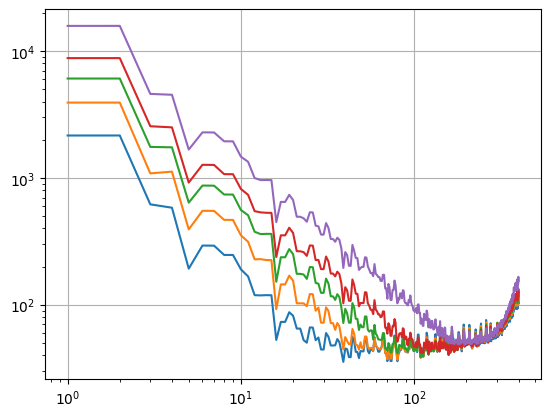

In [ ]:
rec3 = fits.getdata('/raid1/mmenessini/calibration/EKARUS/rec/pyr3.0_40x40_400modes_rec.fits')
rec4 = fits.getdata('/raid1/mmenessini/calibration/EKARUS/rec/pyr4.0_40x40_400modes_rec.fits')
rec5 = fits.getdata('/raid1/mmenessini/calibration/EKARUS/rec/pyr5.0_40x40_400modes_rec.fits')
rec6 = fits.getdata('/raid1/mmenessini/calibration/EKARUS/rec/pyr6.0_40x40_400modes_rec.fits')
rec7 = fits.getdata('/raid1/mmenessini/calibration/EKARUS/rec/pyr8.0_40x40_400modes_rec.fits')

cov3 = np.diag(rec3 @ rec3.T)
cov4 = np.diag(rec4 @ rec4.T)
cov5 = np.diag(rec5 @ rec5.T)
cov6 = np.diag(rec6 @ rec6.T)
cov7 = np.diag(rec7 @ rec7.T)
x = np.arange(len(cov3))+1

plt.figure()
plt.loglog(x,cov3)
plt.loglog(x,cov4)
plt.loglog(x,cov5)
plt.loglog(x,cov6)
plt.loglog(x,cov7)
plt.grid()

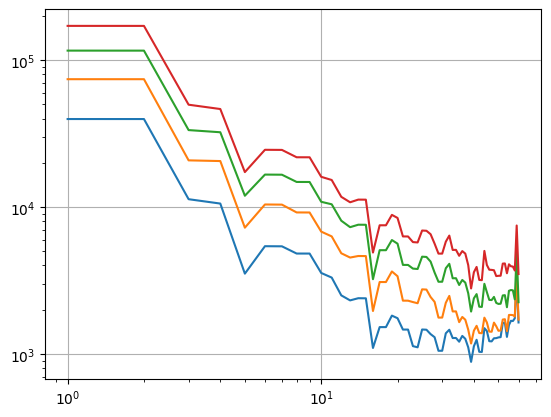

In [ ]:
rec3 = fits.getdata('/raid1/mmenessini/calibration/EKARUS/rec/pyr3.0_10x10_60modes_rec.fits')
rec4 = fits.getdata('/raid1/mmenessini/calibration/EKARUS/rec/pyr4.0_10x10_60modes_rec.fits')
rec5 = fits.getdata('/raid1/mmenessini/calibration/EKARUS/rec/pyr5.0_10x10_60modes_rec.fits')
rec6 = fits.getdata('/raid1/mmenessini/calibration/EKARUS/rec/pyr6.0_10x10_60modes_rec.fits')

cov3 = np.diag(rec3 @ rec3.T)
cov4 = np.diag(rec4 @ rec4.T)
cov5 = np.diag(rec5 @ rec5.T)
cov6 = np.diag(rec6 @ rec6.T)
x = np.arange(len(cov3))+1

plt.figure()
plt.loglog(x,cov3)
plt.loglog(x,cov4)
plt.loglog(x,cov5)
plt.loglog(x,cov6)
plt.grid()

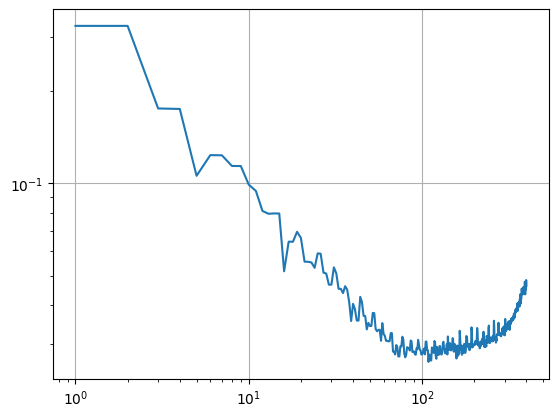

In [ ]:
from specula.mmlib.compute_rec import rec_noise
from specula.mmlib.utils import get_pupil_mask

pyr_mask = get_pupil_mask(npix=120, filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_40x40.fits')
sn = fits.getdata('/raid1/mmenessini/calibration/EKARUS/slopenulls/pyr5.0_40x40_sn.fits')
frame = fits.getdata('/raid1/mmenessini/calibration/EKARUS/frames/pyr5.0_40x40_frame_null.fits')[0]
rec_noise_cov = rec_noise(rec, frame, pyr_mask, sn, RON=0.4, Nphot=1e+6)


plt.figure()
plt.loglog(x,np.sqrt(rec_noise_cov))
plt.grid()

# plt.figure()
# plt.imshow(frame,origin='lower',cmap='RdBu')
# plt.colorbar()

# print(np.sum(frame[pyr_mask]))

Using data directory: /raid1/mmenessini/results/EKARUS/20260515_085554
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
Average Strehl Ratio after 200 iterations: 0.7349
psf.fits file not found in /raid1/mmenessini/results/EKARUS/20260515_085554.
pyr_modes.fits or zwfs_modes.fits file(s) not found in /raid1/mmenessini/results/EKARUS/20260515_085554.
coro_psf.fits file not found in /raid1/mmenessini/results/EKARUS/20260515_085554.
coro_psf_profile.fits file not found in /raid1/mmenessini/results/EKARUS/20260515_085554.


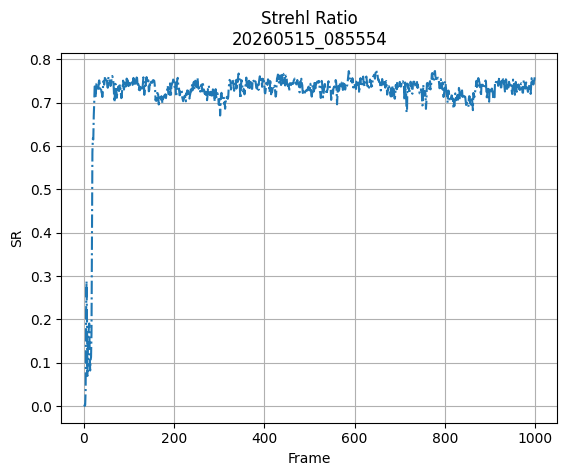

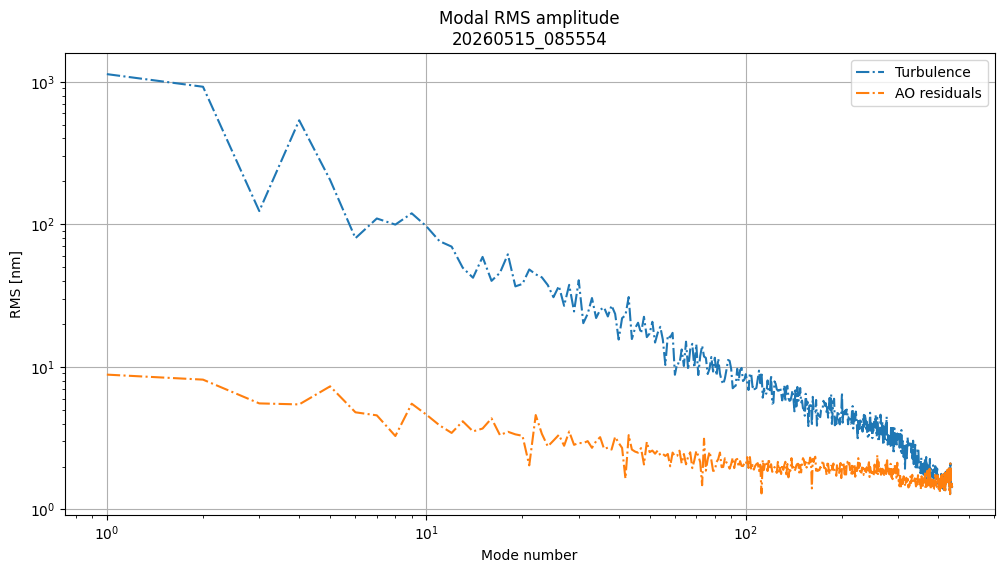

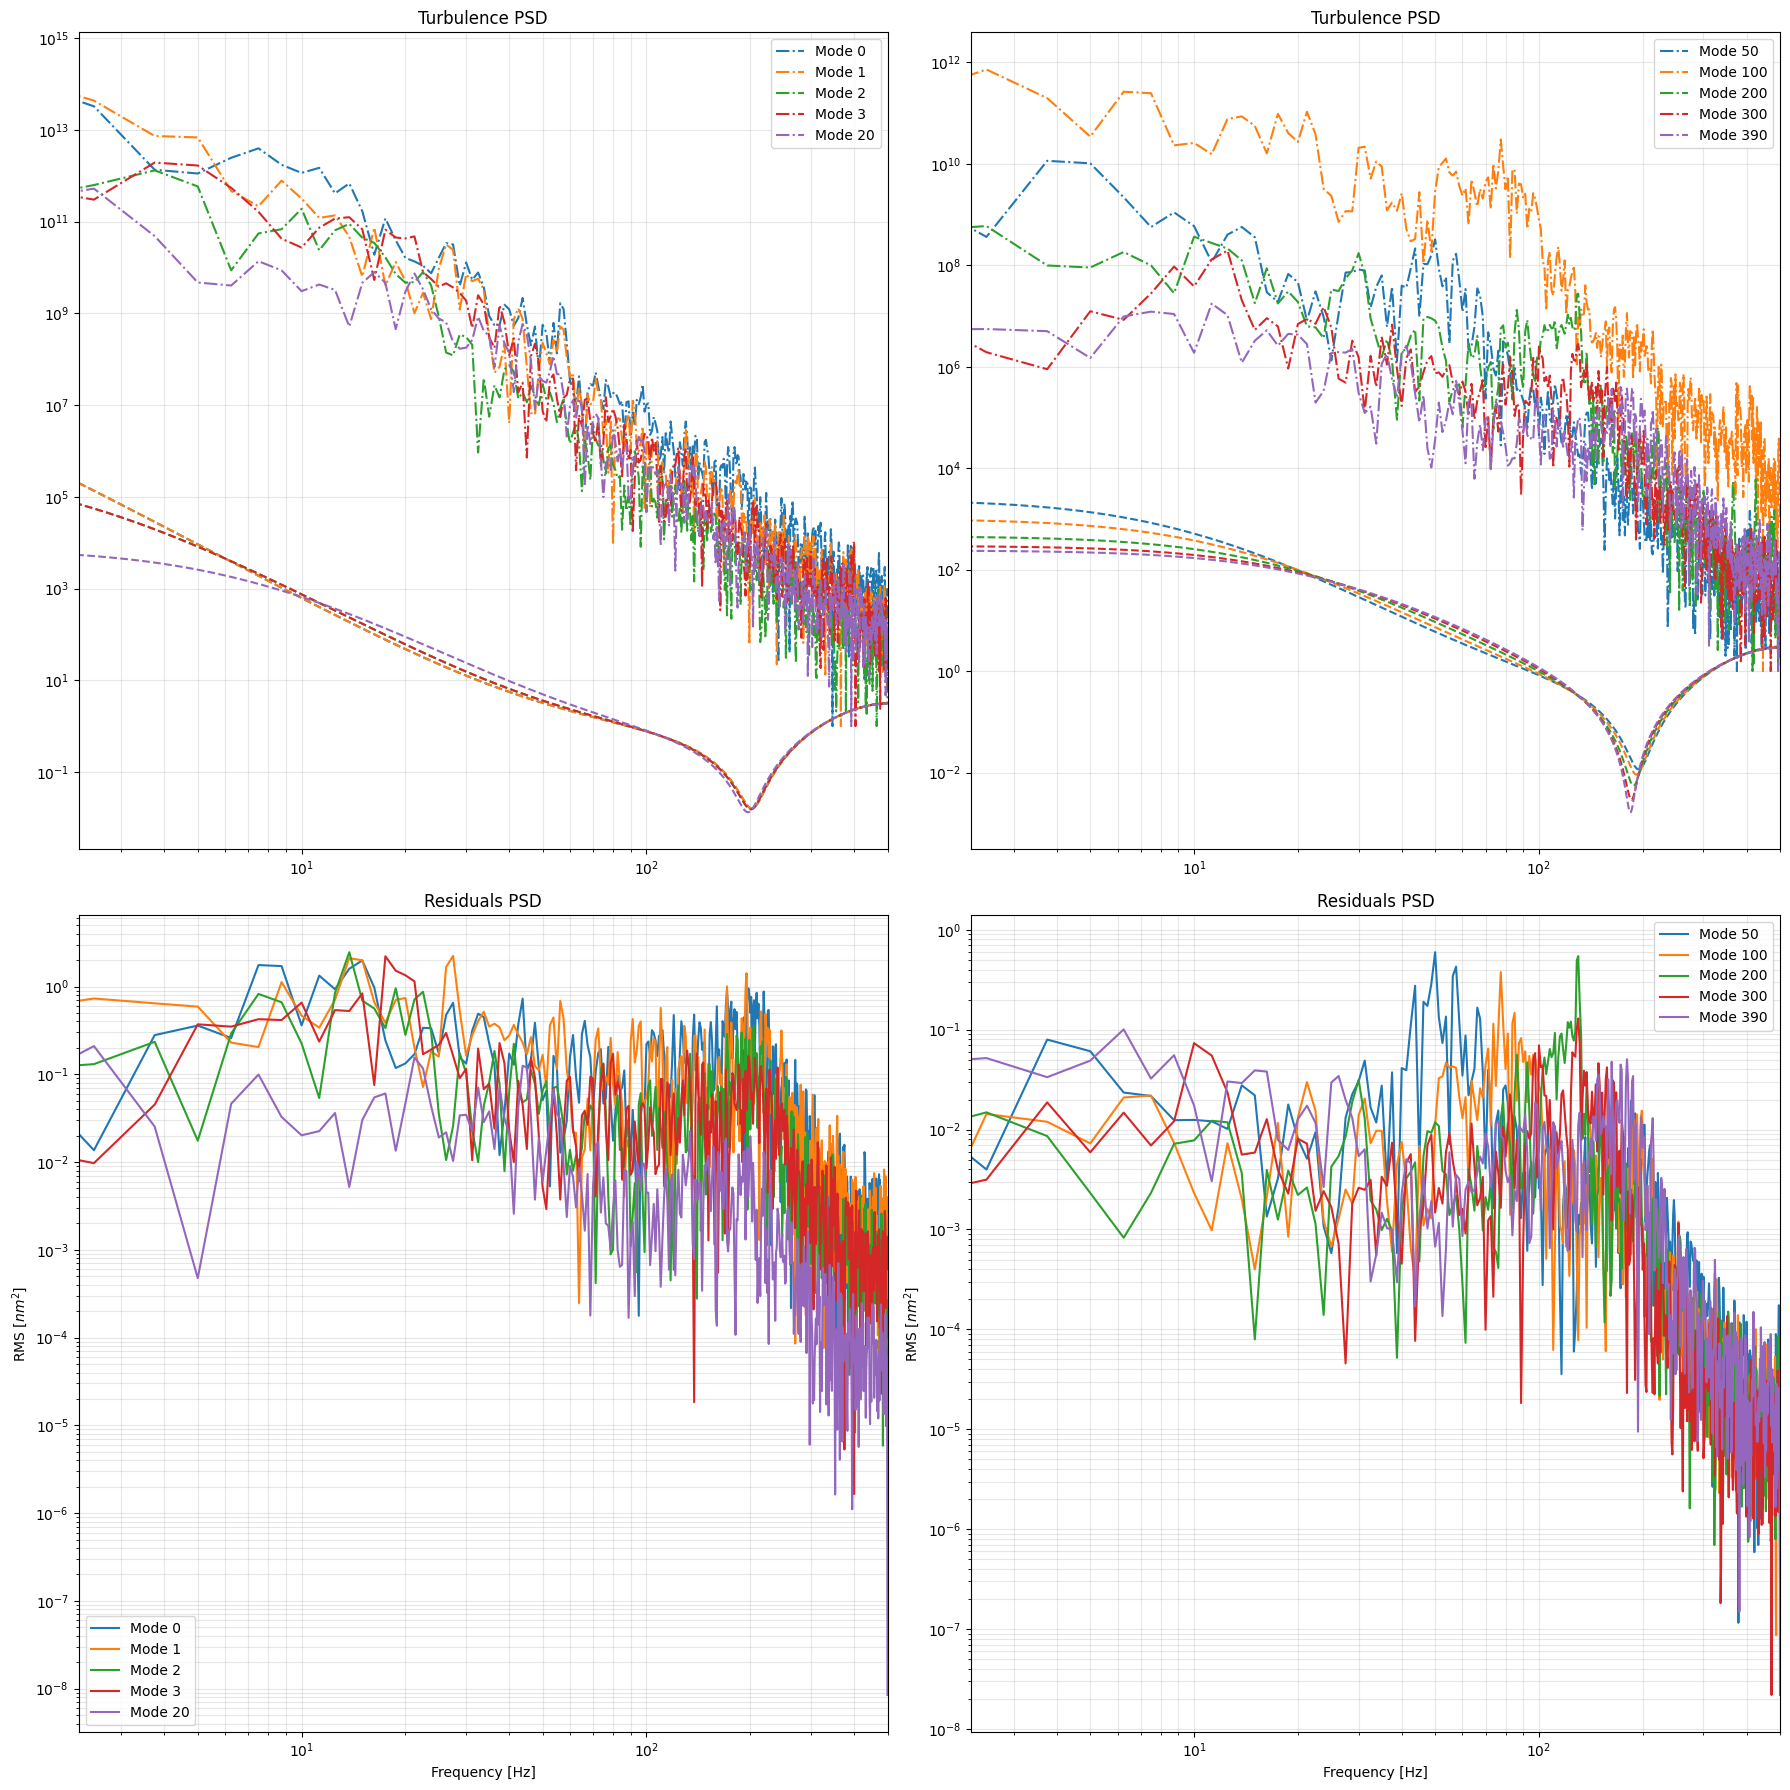

In [ ]:
root_dir = '/raid1/mmenessini/results/EKARUS'
calib_dir = '/raid1/mmenessini/calibration/EKARUS'
plot_output_data(root_dir=root_dir,calib_dir=calib_dir)

In [ ]:

# from specula.mmlib.utils import get_pupil_mask
# pupdatapath = '/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_40x40.fits'
# pyr_mask = get_pupil_mask(filepath=pupdatapath,npix=120,pyr=True)
# # plt.figure()
# # plt.imshow(pyr_mask,origin='lower')
# # plt.colorbar()

# frame = fits.getdata('/raid1/mmenessini/calibration/EKARUS/frames/pyr3.0_40x40_frame_null.fits')[0]    
# plt.figure()
# plt.imshow(frame/np.max(frame)+pyr_mask,origin='lower',cmap='RdBu')
# plt.colorbar()
# thrp = fits.getdata('/raid1/mmenessini/calibration/EKARUS/slopenulls/pyr3.0_40x40_throughput.fits')
# print(thrp)

In [ ]:

# modes = np.array([54,120,400])
# seeings = np.array([1.8,2.0,2.2,2.4,2.6])

# cv = np.zeros([len(seeings),len(modes),435])

# for i,seeing in enumerate(seeings):
#     for j,N in enumerate(modes):
#         cvec = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/data/s{seeing:1.1f}_{N:1.0f}modes_corrvec.fits')
#         cvec = np.maximum(0.0,cvec)
#         cv[i,j,:] = cvec
#         fits.writeto(f'/raid1/mmenessini/calibration/EKARUS/data/s{seeing:1.1f}_{N:1.0f}modes_corrvec.fits',cvec,overwrite=True)

# x = np.arange(435)+1

# for j,N in enumerate(modes):
#     plt.figure()
#     for i,seeing in enumerate(seeings):
#         plt.plot(x,1-cv[i,j,:],label=f'Seeing: {seeing:1.1f}"')
#     plt.xscale('log')
#     plt.legend()
#     plt.title(f'{N:1.0f} modes corrected')
#     plt.grid()